In [3]:
import os
import wfdb
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

# Define the path to your dataset directory
DATA_DIR = "C:/Users/M2-Winterfell/Downloads/electrocardiography-dataset-1.0.3/records500/00000"

# Function to load and extract Lead I and Lead II from a single record
def load_ecg_leads(file_path):
    try:
        # Load the record using wfdb (the file_path should be without extension)
        record = wfdb.rdrecord(file_path)
        
        # Extract Lead I and Lead II (assuming they are the first two leads)
        lead_I = record.p_signal[:, 0]  # Lead I
        lead_II = record.p_signal[:, 1]  # Lead II
        
        return lead_I, lead_II
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

# Function to load only the first 1000 ECG records
def load_first_n_ecg_data(data_dir, n=1000):
    all_lead_I = []
    all_lead_II = []
    
    count = 0  # To keep track of the number of records loaded
    
    # Traverse through all subdirectories in records500
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc="Loading ECG files"):
            if file.endswith("_hr.dat"):  # Look for files with the _hr suffix
                # Stop loading after reaching the first n records
                if count >= n:
                    break
                
                # Construct the base filename (removing the '_hr.dat' extension)
                base_filename = file.replace("_hr.dat", "_hr")
                record_path = os.path.join(root, base_filename)
                
                # Load Lead I and Lead II
                lead_I, lead_II = load_ecg_leads(record_path)
                
                if lead_I is not None and lead_II is not None:
                    all_lead_I.append(lead_I)
                    all_lead_II.append(lead_II)
                    count += 1
                else:
                    print(f"Skipping record: {base_filename}")

        if count >= n:  # Break the outer loop as well
            break
    
    # Convert lists to NumPy arrays if data was loaded
    if all_lead_I and all_lead_II:
        all_lead_I = np.array(all_lead_I)  # Shape: (num_records, samples_per_record)
        all_lead_II = np.array(all_lead_II)  # Shape: (num_records, samples_per_record)
    else:
        all_lead_I = np.array([])  # Empty array if no data
        all_lead_II = np.array([])  # Empty array if no data
    
    return all_lead_I, all_lead_II

# Load only the first 1000 ECG records from records500
lead_I_data, lead_II_data = load_first_n_ecg_data(DATA_DIR, n=1000)

# Check if data was loaded successfully
if lead_I_data.size > 0 and lead_II_data.size > 0:
    print(f"Total records loaded: {lead_I_data.shape[0]}")
    print(f"Each record has {lead_I_data.shape[1]} samples per lead.")
    
    # Check shapes
    print("Lead I data shape:", lead_I_data.shape)
    print("Lead II data shape:", lead_II_data.shape)
else:
    print("No data was loaded.")


Loading ECG files: 100%|██████████| 1974/1974 [00:02<00:00, 705.77it/s]


Total records loaded: 987
Each record has 5000 samples per lead.
Lead I data shape: (987, 5000)
Lead II data shape: (987, 5000)


In [7]:
import pandas as pd

# 假设 lead_I_data 是你的 Lead I 数据，形状为 (987, 5000)
# 将 NumPy 数组转换为 pandas DataFrame
lead_I_df = pd.DataFrame(lead_I_data)

# 将 DataFrame 保存为 CSV 文件
lead_I_df.to_csv("lead_I_data.csv", index=False)

print("Lead I data has been saved to lead_I_data.csv")

Lead I data has been saved to lead_I_data.csv


- Feature extraction: morphological features (like PR interval, QRS duration, and wave amplitudes) and Heart Rate Variability (HRV) metrics (such as SDNN, RMSSD, and LF/HF ratio)
- Feature used to train Logistic Regression model
- Supervised learning: Metric inclusing AUC, F1 score, accuracy and Equal Error Rate(EER)
- Feature importance analysis: Assess impact of individual features on classification decision.

SVM with Pan-Tompkins algorithm

- Pan-Tompkins algorithm for R-peak detection
- SVM classifier within Pipeline that includes standardization
- GridSearchCV for hyperparameter model tuning of SVM


Extracting features using Pan-Tompkins algorithm...
Feature matrix shape: (987, 10)

Best Parameters: {'svm__C': 0.1, 'svm__gamma': 1}

Classification Report:
              precision    recall  f1-score   support

        Real       0.65      0.24      0.35       100
   Synthetic       0.53      0.87      0.66        98

    accuracy                           0.55       198
   macro avg       0.59      0.55      0.50       198
weighted avg       0.59      0.55      0.50       198

AUC-ROC: 0.382


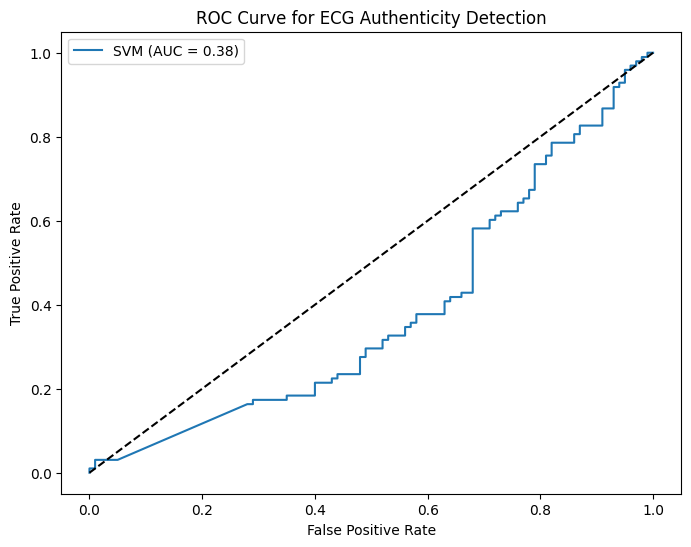

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from biosppy.signals.ecg import engzee_segmenter  # Pan-Tompkins implementation
import matplotlib.pyplot as plt

# ---------------------------
# 0. Prepare Labels (Modify according to your actual data source)
# ---------------------------
# Assuming first 500 are real, rest 487 are synthetic (modify as needed)
n_real = 500
n_fake = 487
y = np.concatenate([np.zeros(n_real), np.ones(n_fake)])

# ---------------------------
# 1. Enhanced Feature Extraction with Pan-Tompkins
# ---------------------------
def extract_ecg_features(signal, sampling_rate=500):
    """Extract comprehensive ECG features using Pan-Tompkins R-peak detection"""
    features = []
    
    # Time-domain features
    features.append(np.mean(signal))          # Mean amplitude
    features.append(np.std(signal))           # Standard deviation
    features.append(np.ptp(signal))           # Peak-to-peak amplitude
    features.append(np.percentile(signal, 75) - np.percentile(signal, 25))  # IQR
    
    # Frequency-domain features
    fft_vals = np.abs(np.fft.rfft(signal))
    features.append(np.mean(fft_vals))        # Mean spectral power
    features.append(np.argmax(fft_vals))      # Dominant frequency component
    
    # R-peak detection using Pan-Tompkins algorithm
    try:
        r_peaks = engzee_segmenter(signal=signal, sampling_rate=sampling_rate)[0]
        rr_intervals = np.diff(r_peaks) / sampling_rate  # Convert to seconds
        
        if len(rr_intervals) > 1:
            # Heart rate variability features
            features.append(np.mean(rr_intervals))     # Mean RR interval
            features.append(np.std(rr_intervals))      # SDNN
            features.append(np.sqrt(np.mean(np.square(np.diff(rr_intervals)))))  # RMSSD
            
            # Morphological features
            qrs_durations = []
            for peak in r_peaks:
                start = max(0, peak - 50)
                end = min(len(signal), peak + 50)
                qrs_durations.append(end - start)
            features.append(np.mean(qrs_durations))    # Average QRS duration
        else:
            # Fallback values if insufficient R-peaks detected
            features.extend([0, 0, 0, 0])
    except Exception as e:
        print(f"R-peak detection error: {e}")
        features.extend([0, 0, 0, 0])
    
    return np.array(features)

# ---------------------------
# 2. Feature Extraction from Lead I Data
# ---------------------------
print("\nExtracting features using Pan-Tompkins algorithm...")
X_features = np.array([extract_ecg_features(sig) for sig in lead_I_data])
print("Feature matrix shape:", X_features.shape)

# Remove samples with invalid features (if any)
valid_indices = ~np.any(np.isnan(X_features), axis=1)
X_clean = X_features[valid_indices]
y_clean = y[valid_indices]

# ---------------------------
# 3. Data Preprocessing
# ---------------------------
# Split dataset with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    stratify=y_clean,
    random_state=42
)

# Create preprocessing pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced'))
])

# Hyperparameter tuning
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 1]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# ---------------------------
# 4. Evaluation
# ---------------------------
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nBest Parameters:", grid_search.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Synthetic']))

# Calculate AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.3f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ECG Authenticity Detection')
plt.legend()
plt.show()

动态时间规整（Dynamic Time Warping）：比较ECG信号的形态相似性，真人ECG信号的形态通常更复杂，而机器人生成的ECG可能过于平滑

Template Matching and signal similarity and distance-based comparison and Random Forest for classification

- Measure the similarity between ECG signals by comparing them to multiple real ECG templates
- Calculating the pairwise DTW distances between the signals and randomly chosen templates
- resulting distance matrix used as features for training a Random Forest(RF) classifier

              precision    recall  f1-score   support

         0.0       0.52      0.45      0.48        98
         1.0       0.52      0.59      0.55       100

    accuracy                           0.52       198
   macro avg       0.52      0.52      0.52       198
weighted avg       0.52      0.52      0.52       198



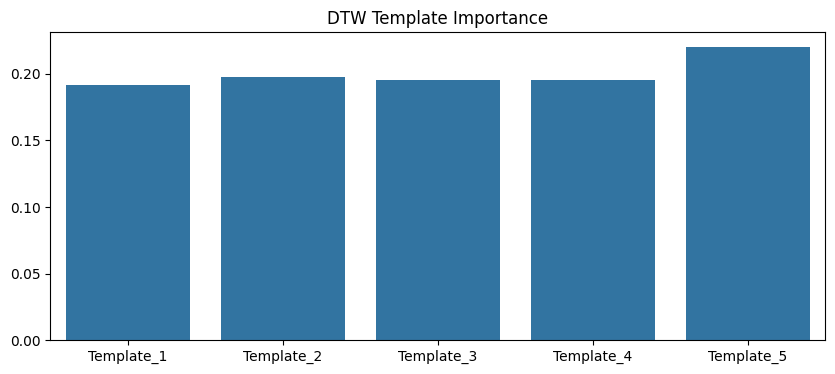

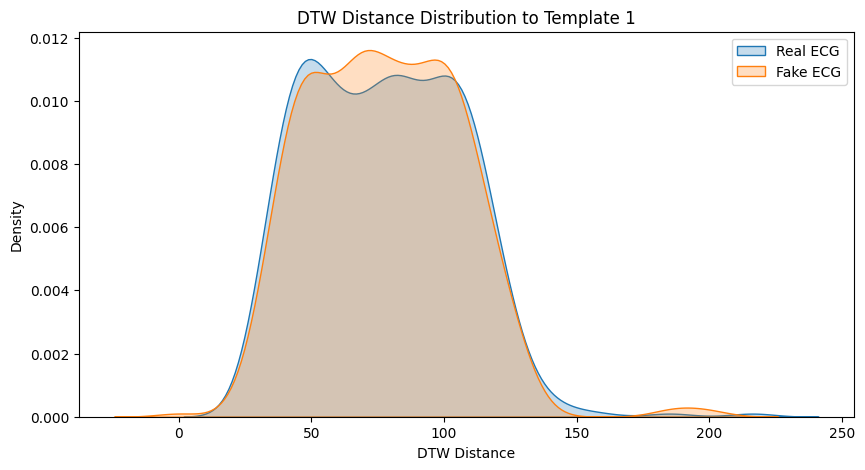

In [6]:
from scipy.signal import resample
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize each ECG signal (normalize independently per sample)
scaler = MinMaxScaler()
normalized_data = np.array([scaler.fit_transform(lead.reshape(-1, 1)).flatten() for lead in lead_I_data])

# Downsample the signals to 500 points (reduce computation while retaining shape features)
downsampled_data = np.array([resample(lead, 500) for lead in normalized_data])

# Split into 'real' and 'generic' data (first 500 records are 'real')
real_data = downsampled_data[:500] 
fake_data = downsampled_data[500:]

# Randomly select N real samples as templates
num_templates = 5
template_indices = np.random.choice(real_data.shape[0], num_templates, replace=False)
templates = real_data[template_indices]

# Custom DTW distance function to compute pairwise DTW distances
def dtw_distance_matrix(data, templates):
    n_samples = data.shape[0]
    n_templates = templates.shape[0]
    dist_matrix = np.zeros((n_samples, n_templates))
    
    for i in range(n_samples):
        for j in range(n_templates):
            # Ensure that data[i] and templates[j] are 1D arrays
            sample = data[i]
            template = templates[j]
            
            # Convert each signal into a list of tuples (e.g., [(sample[0], 0), (sample[1], 0), ...])
            sample_tuples = [(value, 0) for value in sample]
            template_tuples = [(value, 0) for value in template]
            
            # Check and print the shapes for debugging
            # print(f"Shape of data[{i}]: {sample.shape}, Shape of templates[{j}]: {template.shape}")
            # print(f"Sample tuples: {sample_tuples[:5]}, Template tuples: {template_tuples[:5]}")
            
            # Now, pass the sample and template in tuple format to fastdtw
            distance, _ = fastdtw(sample_tuples, template_tuples, dist=euclidean)
            dist_matrix[i, j] = distance
            
    return dist_matrix

# Calculate DTW distances for each sample against all templates
X = dtw_distance_matrix(downsampled_data, templates)

# Define labels for the classification task (1 for 'real' and 0 for 'generic')
y = np.concatenate([np.ones(real_data.shape[0]), np.zeros(fake_data.shape[0])])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
clf.fit(X_train, y_train)

# Evaluate the classifier
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Plot feature importance
feature_importance = clf.feature_importances_
plt.figure(figsize=(10, 4))
sns.barplot(x=[f"Template_{i+1}" for i in range(num_templates)], y=feature_importance[:num_templates])
plt.title("DTW Template Importance")
plt.show()

# Plot DTW distance distribution for each class (real vs. fake)

# Ensure no NaN or Inf values are in X (DTW distance matrix)
X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

plt.figure(figsize=(10, 5))
sns.kdeplot(X_clean[y == 0, 0], label="Real ECG", fill=True)
sns.kdeplot(X_clean[y == 1, 0], label="Fake ECG", fill=True)

plt.title("DTW Distance Distribution to Template 1")
plt.xlabel("DTW Distance")
plt.legend()
plt.show()


Loading Lead I from from_006_chkp_2500_150k: 100%|██████████| 2000/2000 [00:08<00:00, 222.74file/s]


Total Lead I records loaded from real data: 2000
Total Lead I records loaded from fake data: 2000


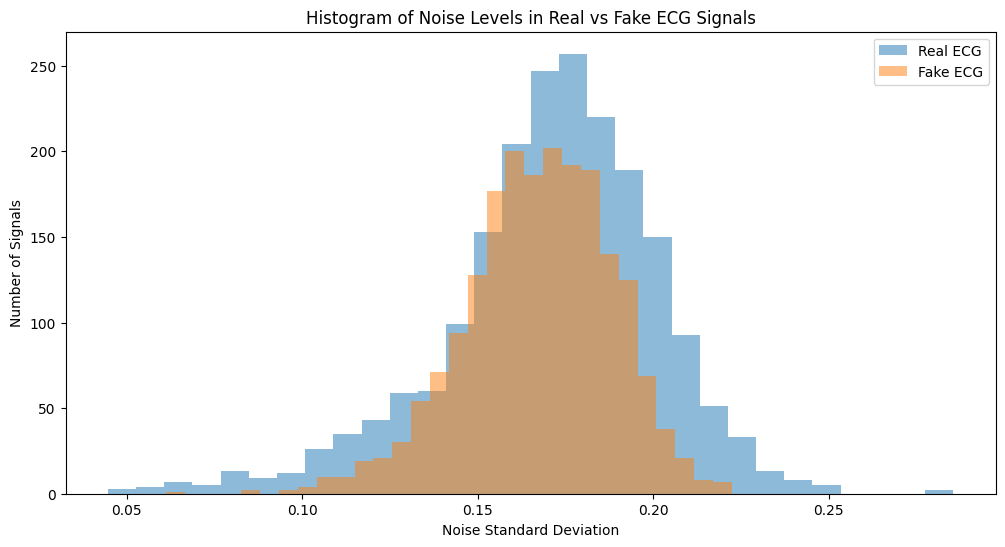

C:\Users\M2-Winterfell\AppData\Local\Temp\ipykernel_9988\1285089950.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([noise_std_real, noise_std_fake], labels=["Real ECG", "Fake ECG"])


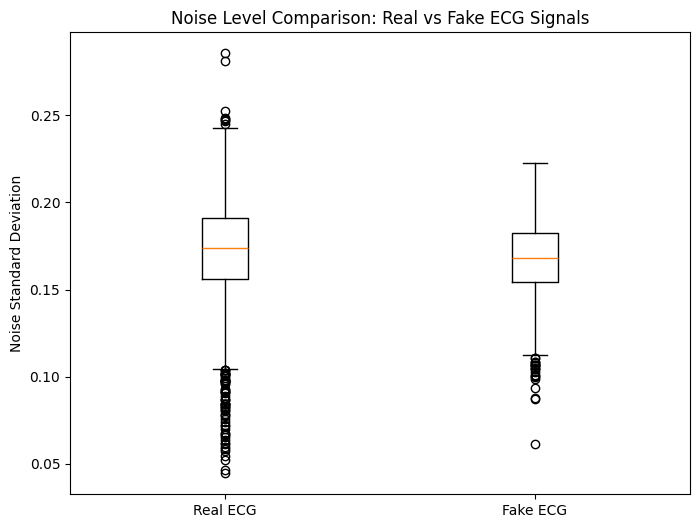

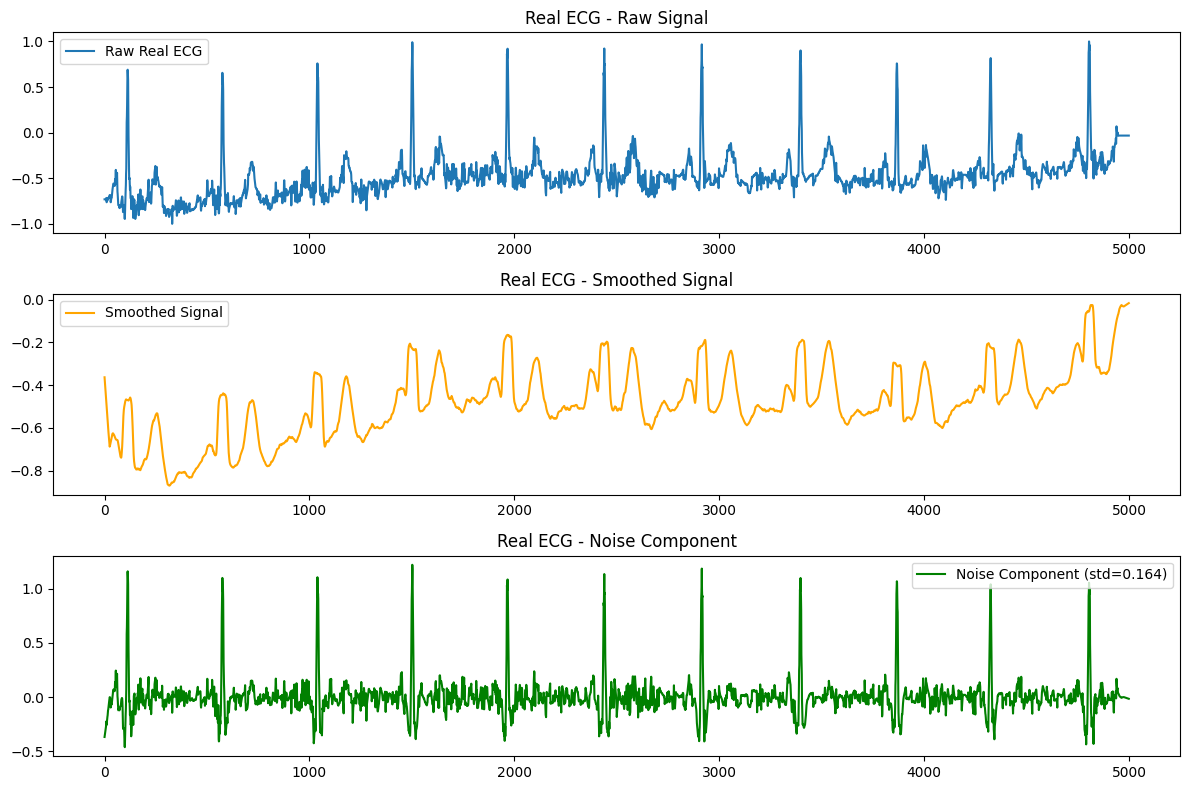

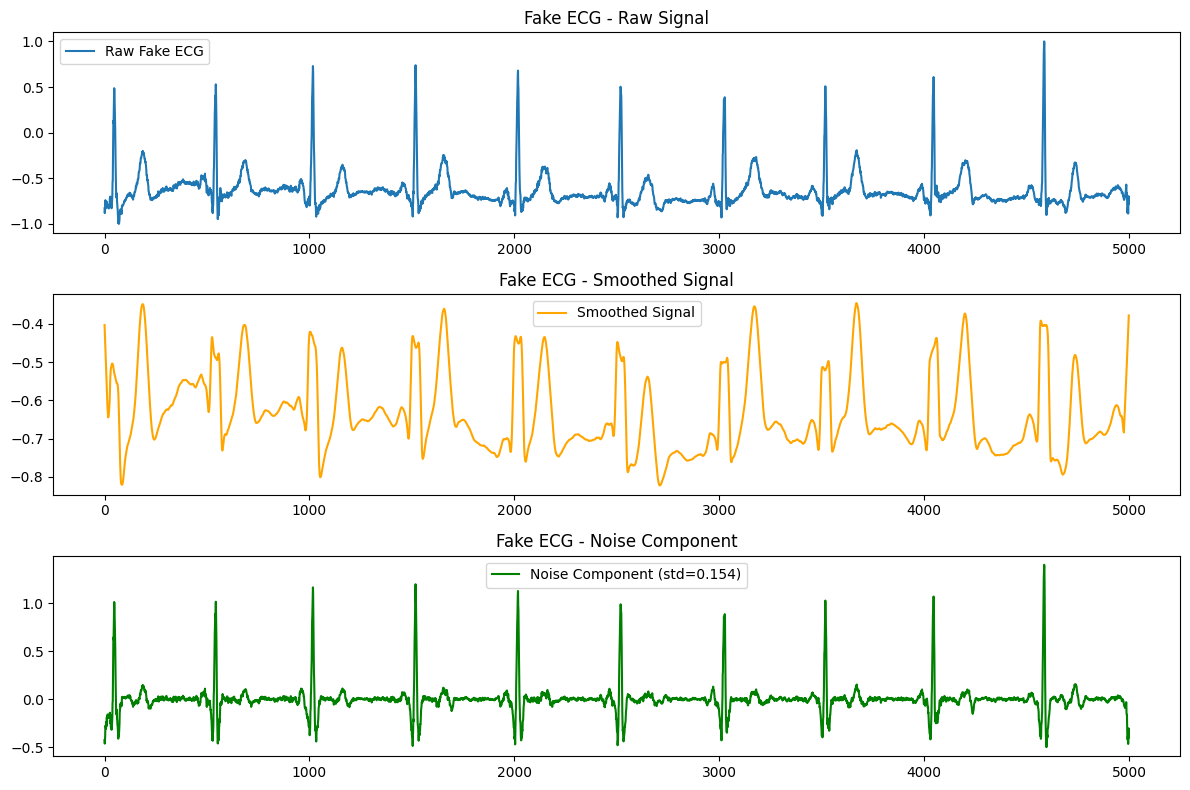

In [1]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------------------
# Data Loading and Preprocessing
# -------------------------------

# Define the paths to your dataset directories
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/pulse2pulse_150k/from_006_chkp_2500_150k"
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"

# Function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        # Load the .asc file (assuming it's space or tab-delimited)
        ecg_data = np.loadtxt(file_path)
        # Extract Lead I (assuming first column is Lead I)
        lead_I = ecg_data[:, 0]
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Function to load exactly n Lead I ECG records from a specified directory with a progress bar
def load_exactly_n_lead_I_from_directory(data_dir, n=2000):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Load exactly 2000 Lead I ECG records from both directories
lead_I_real = load_exactly_n_lead_I_from_directory(DATA_DIR_REAL, n=2000)
lead_I_fake = load_exactly_n_lead_I_from_directory(DATA_DIR_FAKE, n=2000)

if lead_I_fake.size > 0 and lead_I_real.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")

# Normalize each ECG signal between -1 and 1
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

# -------------------------------
# Noise Detection and Visualization
# -------------------------------

# Here we define a function to estimate the "noise" in each ECG signal.
# The idea is to smooth the signal with a moving average filter (as a simple low-pass filter)
# and then compute the standard deviation of the difference between the original and the smoothed signal.
def compute_noise_std(signal, window_size=50):
    # Compute a moving average to obtain a smooth version of the signal.
    # Adjust window_size if needed to best capture the underlying trend.
    smooth_signal = np.convolve(signal, np.ones(window_size)/window_size, mode='same')
    noise_component = signal - smooth_signal
    noise_std = np.std(noise_component)
    return noise_std, smooth_signal, noise_component

# Compute the noise standard deviation for each signal in both datasets.
noise_std_real = []
for signal in lead_I_real:
    noise_std, _, _ = compute_noise_std(signal, window_size=50)
    noise_std_real.append(noise_std)

noise_std_fake = []
for signal in lead_I_fake:
    noise_std, _, _ = compute_noise_std(signal, window_size=50)
    noise_std_fake.append(noise_std)

# Convert lists to numpy arrays for further processing if needed.
noise_std_real = np.array(noise_std_real)
noise_std_fake = np.array(noise_std_fake)

# -------------------------------
# Visualization
# -------------------------------

# 1. Histogram of noise levels for real vs fake ECG signals
plt.figure(figsize=(12, 6))
plt.hist(noise_std_real, bins=30, alpha=0.5, label="Real ECG")
plt.hist(noise_std_fake, bins=30, alpha=0.5, label="Fake ECG")
plt.xlabel("Noise Standard Deviation")
plt.ylabel("Number of Signals")
plt.title("Histogram of Noise Levels in Real vs Fake ECG Signals")
plt.legend()
plt.show()

# 2. Boxplot to compare the noise distributions
plt.figure(figsize=(8, 6))
plt.boxplot([noise_std_real, noise_std_fake], labels=["Real ECG", "Fake ECG"])
plt.ylabel("Noise Standard Deviation")
plt.title("Noise Level Comparison: Real vs Fake ECG Signals")
plt.show()

# 3. Plot sample signals and their noise components
# Let's visualize one sample from each category (you can loop or pick more samples as needed)

sample_index = 0  # change index to see different samples

# For a real ECG sample
real_signal = lead_I_real[sample_index]
real_noise_std, real_smooth, real_noise = compute_noise_std(real_signal, window_size=50)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(real_signal, label="Raw Real ECG")
plt.title("Real ECG - Raw Signal")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(real_smooth, label="Smoothed Signal", color='orange')
plt.title("Real ECG - Smoothed Signal")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(real_noise, label=f"Noise Component (std={real_noise_std:.3f})", color='green')
plt.title("Real ECG - Noise Component")
plt.legend()

plt.tight_layout()
plt.show()

# For a fake ECG sample
fake_signal = lead_I_fake[sample_index]
fake_noise_std, fake_smooth, fake_noise = compute_noise_std(fake_signal, window_size=50)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(fake_signal, label="Raw Fake ECG")
plt.title("Fake ECG - Raw Signal")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(fake_smooth, label="Smoothed Signal", color='orange')
plt.title("Fake ECG - Smoothed Signal")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(fake_noise, label=f"Noise Component (std={fake_noise_std:.3f})", color='green')
plt.title("Fake ECG - Noise Component")
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# Interpretation
# -------------------------------
#
# You can compare the histograms and boxplots to see if one dataset has consistently higher or more variable noise levels.
# For instance, if the real ECG signals show a higher average noise standard deviation than the fake ones,
# that could be an indication of the natural myoelectric interference and baseline drift present in real data.
#
# Keep in mind that this method (a simple moving average subtraction) is one way to quantify noise.
# Depending on your application, you might consider more advanced noise estimation techniques or frequency-domain analyses.
